# Rollout-training ablation data

Load all available rollout-training-ablation JSONL results into one tidy DataFrame. This notebook intentionally performs no analysis or visualization.

The DataFrame retains records from incomplete in-progress files; downstream analysis can decide whether to filter to completed configurations.

In [2]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd() if (Path.cwd() / 'derived').is_dir() else Path.cwd().parent
RESULTS_DIR = REPO_ROOT / 'derived' / 'results' / 'rollout_training_ablation'
FILENAME_PATTERN = re.compile(
    r'^rollouttrain_(?P<dynamic>diffusion|wave|coupled_oscillator)_'
    r'(?P<topology>ring|grid|torus|doorway|swisscheese)_'
    r'models(?P<models>\d+)_epochs(?P<epochs>\d+)_nodes(?P<num_nodes>\d+)_'
    r'episodes(?P<num_episodes>\d+)_bins(?P<num_bins>\d+)_events(?P<events_per_bin>\d+)_'
    r'dropint(?P<raindrop_interval>\d+)_tau(?P<event_threshold>[0-9p]+)_'
    r'trainroll(?P<rollout_train_steps>\d+)_rollhorizon(?P<rollout_horizon>\d+)_'
    r'dt(?P<synthetic_dt>[0-9p]+)_gamma(?P<synthetic_gamma>[0-9p]+)_'
    r'omega(?P<synthetic_omega>[0-9p]+)_forcescale(?P<synthetic_force_scale>[0-9p]+)_'
    r'seed(?P<seed>\d+)\.jsonl$'
)


In [3]:
def decode_numeric_tag(value: str) -> float:
    return float(value.replace('p', '.'))


def load_rollout_training_results(results_dir: Path) -> pd.DataFrame:
    paths = sorted(results_dir.glob('rollouttrain_*.jsonl'))
    if not paths:
        raise FileNotFoundError(f'No rollout-training JSONLs found in {results_dir}')

    records: list[dict] = []
    for path in paths:
        match = FILENAME_PATTERN.fullmatch(path.name)
        if match is None:
            raise ValueError(f'Unexpected rollout-training filename: {path.name}')

        raw_metadata = match.groupdict()
        metadata = {
            key: (decode_numeric_tag(value) if key.startswith(('event_threshold', 'synthetic_')) else value)
            for key, value in raw_metadata.items()
        }
        metadata.update({
            key: int(value)
            for key, value in raw_metadata.items()
            if key not in {'dynamic', 'topology', 'event_threshold', 'synthetic_dt', 'synthetic_gamma', 'synthetic_omega', 'synthetic_force_scale'}
        })

        with path.open(encoding='utf-8') as handle:
            for line_number, line in enumerate(handle, start=1):
                row = json.loads(line)
                row['source_file'] = path.name
                row['source_line'] = line_number
                row.update(metadata)
                records.append(row)

    # Flatten scalar metric dictionaries one level while retaining detailed
    # rollout curves as object-valued columns.
    return pd.json_normalize(records, sep='.', max_level=1)


rollouttrain_df = load_rollout_training_results(RESULTS_DIR)
rollouttrain_df


,run,seed,epoch,source_file,source_line,dynamic,topology,models,epochs,num_nodes,...,train_step.qdot_norm_mean,train_step.qddot_norm_mean,train_step.H_tot_mean,train_step.q_norm_mean,train_step.p_norm_mean,train_step.dqdt_norm_mean,train_step.dpdt_norm_mean,train_step.dqdt_next_norm_mean,val.early_active_force_mse,val.persistent_early_active_force_mse
0,fnn,0,1,rollouttrain_coupled_oscillator_doorway_models...,1,coupled_oscillator,doorway,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fnn,0,2,rollouttrain_coupled_oscillator_doorway_models...,2,coupled_oscillator,doorway,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fnn,0,3,rollouttrain_coupled_oscillator_doorway_models...,3,coupled_oscillator,doorway,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fnn,0,4,rollouttrain_coupled_oscillator_doorway_models...,4,coupled_oscillator,doorway,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fnn,0,5,rollouttrain_coupled_oscillator_doorway_models...,5,coupled_oscillator,doorway,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14945,settransformer/hnn,0,16,rollouttrain_wave_torus_models7_epochs20_nodes...,136,wave,torus,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14946,settransformer/hnn,0,17,rollouttrain_wave_torus_models7_epochs20_nodes...,137,wave,torus,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14947,settransformer/hnn,0,18,rollouttrain_wave_torus_models7_epochs20_nodes...,138,wave,torus,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14948,settransformer/hnn,0,19,rollouttrain_wave_torus_models7_epochs20_nodes...,139,wave,torus,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
def explode_rollout_by_step(
    df: pd.DataFrame,
    curve_col: str = "rollout_test.rollout_by_step",
) -> pd.DataFrame:
    id_cols = [
        "dynamic",
        "topology",
        "run",
        "seed",
        "epoch",
        "rollout_train_steps",
        "rollout_horizon",
        "num_nodes",
        "synthetic_dt",
        "synthetic_gamma",
        "synthetic_omega",
        "synthetic_force_scale",
    ]

    records = []

    for _, row in df[df[curve_col].notna()].iterrows():
        curve = row[curve_col]

        for horizon, metrics in curve.items():
            record = {
                col: row[col]
                for col in id_cols
                if col in row.index
            }

            record["horizon"] = int(horizon)
            record.update(metrics)
            records.append(record)

    return pd.DataFrame(records)


rollouttrain_test = explode_rollout_by_step(
    rollouttrain_df,
    curve_col="rollout_test.rollout_by_step",
)

# Keep the two main dynamics and the complete seed.
rollouttrain_test = rollouttrain_test[
    rollouttrain_test["dynamic"].isin(["diffusion", "wave"])
    & rollouttrain_test["seed"].eq(0)
].copy()

# This ablation asks:
# "if trained for k rollout steps, how well do we perform at step 20?"
rollouttrain_h20 = rollouttrain_test[
    rollouttrain_test["horizon"].eq(20)
].copy()

rollouttrain_h20 = (
    rollouttrain_h20
    .sort_values(
        [
            "dynamic",
            "topology",
            "run",
            "rollout_train_steps",
        ]
    )
    .reset_index(drop=True)
)

print("rows:", len(rollouttrain_h20))
rollouttrain_h20

rows: 350


,dynamic,topology,run,seed,epoch,rollout_train_steps,rollout_horizon,num_nodes,synthetic_dt,synthetic_gamma,...,event_precision,event_recall,event_specificity,event_f1,event_auroc,event_auprc,event_balanced_acc,event_false_positive_rate,event_pred_positive_rate,event_true_positive_rate
0,diffusion,doorway,deepsets/tgn_gru,0,20,1,20,64,0.1,0.15,...,0.973684,0.870588,0.976471,0.919255,0.974862,0.932119,0.923529,0.023529,0.447059,0.5
1,diffusion,doorway,deepsets/tgn_gru,0,20,2,20,64,0.1,0.15,...,0.930818,0.870588,0.935294,0.899696,0.947924,0.889883,0.902941,0.064706,0.467647,0.5
2,diffusion,doorway,deepsets/tgn_gru,0,20,5,20,64,0.1,0.15,...,0.948718,0.870588,0.952941,0.907975,0.963495,0.911561,0.911765,0.047059,0.458824,0.5
3,diffusion,doorway,deepsets/tgn_gru,0,20,10,20,64,0.1,0.15,...,0.919255,0.870588,0.923529,0.894260,0.957958,0.894048,0.897059,0.076471,0.473529,0.5
4,diffusion,doorway,deepsets/tgn_gru,0,20,20,20,64,0.1,0.15,...,0.925000,0.870588,0.929412,0.896970,0.959031,0.893550,0.900000,0.070588,0.470588,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,wave,torus,sum/tgn_gru,0,20,1,20,64,0.1,0.15,...,0.927536,0.892430,0.930279,0.909645,0.894889,0.887487,0.911355,0.069721,0.481076,0.5
346,wave,torus,sum/tgn_gru,0,20,2,20,64,0.1,0.15,...,0.916016,0.934263,0.914343,0.925049,0.971675,0.972176,0.924303,0.085657,0.509960,0.5
347,wave,torus,sum/tgn_gru,0,20,5,20,64,0.1,0.15,...,0.974576,0.687251,0.982072,0.806075,0.908299,0.937097,0.834661,0.017928,0.352590,0.5
348,wave,torus,sum/tgn_gru,0,20,10,20,64,0.1,0.15,...,0.971193,0.940239,0.972112,0.955466,0.980750,0.969379,0.956175,0.027888,0.484064,0.5


In [5]:
display(
    rollouttrain_h20
    .groupby(["dynamic", "topology", "run"])
    .agg(
        train_steps=("rollout_train_steps", "nunique"),
        rows=("rollout_train_steps", "size"),
    )
    .reset_index()
)

,dynamic,topology,run,train_steps,rows
0,diffusion,doorway,deepsets/tgn_gru,5,5
1,diffusion,doorway,fnn,5,5
2,diffusion,doorway,hopfield/hopfield_update,5,5
3,diffusion,doorway,settransformer/hnn,5,5
4,diffusion,doorway,settransformer/lnn,5,5
...,...,...,...,...,...
65,wave,torus,hopfield/hopfield_update,5,5
66,wave,torus,settransformer/hnn,5,5
67,wave,torus,settransformer/lnn,5,5
68,wave,torus,settransformer/tgn_gru,5,5


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "sans-serif",
    #"font.sans-serif": [PAPER_FONT],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})

In [8]:
DYNAMIC_ORDER = [
    "diffusion",
    "wave",
]

DYNAMIC_LABELS = {
    "diffusion": "Diffusion",
    "wave": "Wave",
}

TOPOLOGY_ORDER = [
    "ring",
    "grid",
    "torus",
    "doorway",
    "swisscheese",
]

TOPOLOGY_LABELS = {
    "ring": "Ring",
    "grid": "Grid",
    "torus": "Torus",
    "doorway": "Doorway",
    "swisscheese": "Swiss cheese",
}

MODEL_ORDER = [
    "fnn",
    "sum/tgn_gru",
    "deepsets/tgn_gru",
    "settransformer/tgn_gru",
    "hopfield/hopfield_update",
    "settransformer/lnn",
    "settransformer/hnn",
]

MODEL_LABELS = {
    "fnn": "FNN",
    "sum/tgn_gru": "Sum + GRU",
    "deepsets/tgn_gru": "DeepSets + GRU",
    "settransformer/tgn_gru": "SetTransformer + GRU",
    "hopfield/hopfield_update": "Hopfield",
    "settransformer/lnn": "LNN",
    "settransformer/hnn": "HNN",
}

BASELINE_COLORS = plt.get_cmap("tab10").colors

MODEL_COLORS = {
    "fnn": "#0072B2",
    "sum/tgn_gru": BASELINE_COLORS[1],
    "deepsets/tgn_gru": BASELINE_COLORS[2],
    "settransformer/tgn_gru": BASELINE_COLORS[3],
    "hopfield/hopfield_update": BASELINE_COLORS[4],
    "settransformer/lnn": BASELINE_COLORS[5],
    "settransformer/hnn": BASELINE_COLORS[6],
}

MODEL_MARKERS = {
    "fnn": "o",
    "sum/tgn_gru": "s",
    "deepsets/tgn_gru": "^",
    "settransformer/tgn_gru": "D",
    "hopfield/hopfield_update": "P",
    "settransformer/lnn": "X",
    "settransformer/hnn": "v",
}

MODEL_LINEWIDTHS = {
    run: 1.7 if run == "fnn" else 1.2
    for run in MODEL_ORDER
}

TRAIN_ROLLOUT_STEPS = [1, 2, 5, 10, 20]

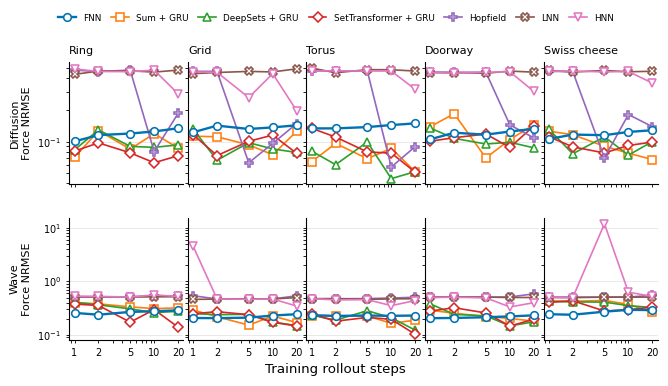

In [9]:
fig, axes = plt.subplots(
    len(DYNAMIC_ORDER),
    len(TOPOLOGY_ORDER),
    figsize=(6.5, 3.8),
    sharex=True,
    sharey="row",
)

legend_handles = {}

for row_idx, dynamic in enumerate(DYNAMIC_ORDER):
    for col_idx, topology in enumerate(TOPOLOGY_ORDER):

        ax = axes[row_idx, col_idx]

        panel = rollouttrain_h20[
            (rollouttrain_h20["dynamic"] == dynamic)
            & (rollouttrain_h20["topology"] == topology)
        ]

        draw_order = [
            run for run in MODEL_ORDER
            if run != "fnn"
        ] + ["fnn"]

        for run in draw_order:

            g = (
                panel[panel["run"] == run]
                .sort_values("rollout_train_steps")
            )

            if g.empty:
                continue

            color = MODEL_COLORS[run]

            line, = ax.plot(
                g["rollout_train_steps"],
                g["force_nrmse"],
                label=MODEL_LABELS[run],
                color=color,
                linewidth=MODEL_LINEWIDTHS[run],
                marker=MODEL_MARKERS[run],
                markersize=5.5,
                markerfacecolor="white",
                markeredgecolor=color,
                markeredgewidth=1.15,
                zorder=4 if run == "fnn" else 2,
            )

            legend_handles.setdefault(run, line)

        if row_idx == 0:
            ax.set_title(
                TOPOLOGY_LABELS[topology],
                loc="left",
            )

        if col_idx == 0:
            ax.set_ylabel(
                f"{DYNAMIC_LABELS[dynamic]}\nForce NRMSE"
            )

        ax.set_xscale("log")
        ax.set_xticks(TRAIN_ROLLOUT_STEPS)
        ax.set_xticklabels(TRAIN_ROLLOUT_STEPS)

        ax.set_yscale("log")

        ax.grid(
            axis="y",
            color="0.88",
            linewidth=0.5,
        )
        ax.grid(axis="x", visible=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            axis="both",
            length=2.5,
            width=0.6,
        )


present_runs = [
    run for run in MODEL_ORDER
    if run in legend_handles
]

fig.legend(
    [legend_handles[run] for run in present_runs],
    [MODEL_LABELS[run] for run in present_runs],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(present_runs),
    frameon=False,
    columnspacing=1.1,
    handlelength=2.0,
)

fig.supxlabel(
    "Training rollout steps",
    y=0.035,
)

fig.subplots_adjust(
    left=0.09,
    right=0.995,
    bottom=0.13,
    top=0.86,
    wspace=0.04,
    hspace=0.28,
)

plt.show()

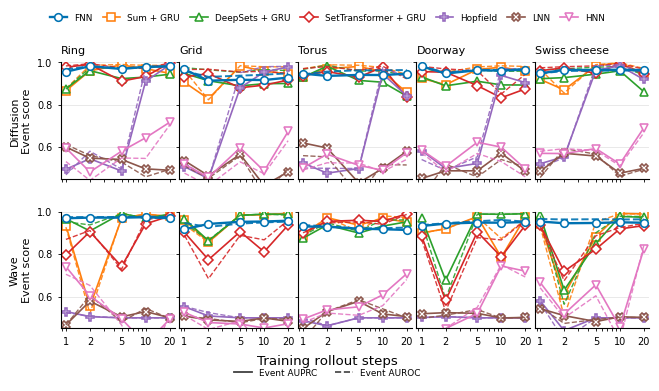

In [10]:
fig, axes = plt.subplots(
    len(DYNAMIC_ORDER),
    len(TOPOLOGY_ORDER),
    figsize=(6.5, 3.8),
    sharex=True,
    sharey="row",
)

legend_handles = {}

for row_idx, dynamic in enumerate(DYNAMIC_ORDER):
    for col_idx, topology in enumerate(TOPOLOGY_ORDER):

        ax = axes[row_idx, col_idx]

        panel = rollouttrain_h20[
            (rollouttrain_h20["dynamic"] == dynamic)
            & (rollouttrain_h20["topology"] == topology)
        ]

        draw_order = [
            run for run in MODEL_ORDER
            if run != "fnn"
        ] + ["fnn"]

        for run in draw_order:

            g = (
                panel[panel["run"] == run]
                .sort_values("rollout_train_steps")
            )

            if g.empty:
                continue

            color = MODEL_COLORS[run]

            # ------------------------------------------------
            # AUPRC: solid + marker
            # ------------------------------------------------

            line_auprc, = ax.plot(
                g["rollout_train_steps"],
                g["event_auprc"],
                label=MODEL_LABELS[run],
                color=color,
                linestyle="-",
                linewidth=MODEL_LINEWIDTHS[run],
                marker=MODEL_MARKERS[run],
                markersize=5.5,
                markerfacecolor="white",
                markeredgecolor=color,
                markeredgewidth=1.15,
                zorder=4 if run == "fnn" else 2,
            )

            legend_handles.setdefault(run, line_auprc)

            # ------------------------------------------------
            # AUROC: dashed, no marker
            # ------------------------------------------------

            ax.plot(
                g["rollout_train_steps"],
                g["event_auroc"],
                color=color,
                linestyle="--",
                linewidth=1.4 if run == "fnn" else 1.0,
                alpha=0.90,
                zorder=3 if run == "fnn" else 2,
            )

        if row_idx == 0:
            ax.set_title(
                TOPOLOGY_LABELS[topology],
                loc="left",
            )

        if col_idx == 0:
            ax.set_ylabel(
                f"{DYNAMIC_LABELS[dynamic]}\nEvent score"
            )

        ax.set_xscale("log")
        ax.set_xticks(TRAIN_ROLLOUT_STEPS)
        ax.set_xticklabels(TRAIN_ROLLOUT_STEPS)

        ax.set_ylim(0.45, 1.0)

        ax.grid(
            axis="y",
            color="0.88",
            linewidth=0.5,
        )
        ax.grid(axis="x", visible=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            axis="both",
            length=2.5,
            width=0.6,
        )


# ============================================================
# Model legend
# ============================================================

present_runs = [
    run for run in MODEL_ORDER
    if run in legend_handles
]

fig.legend(
    [legend_handles[run] for run in present_runs],
    [MODEL_LABELS[run] for run in present_runs],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(present_runs),
    frameon=False,
    columnspacing=1.1,
    handlelength=2.0,
)


# ============================================================
# Metric legend
# ============================================================

metric_handles = [
    Line2D(
        [0], [0],
        color="0.25",
        linestyle="-",
        linewidth=1.3,
        label="Event AUPRC",
    ),
    Line2D(
        [0], [0],
        color="0.25",
        linestyle="--",
        linewidth=1.2,
        label="Event AUROC",
    ),
]

fig.legend(
    handles=metric_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    frameon=False,
)

fig.supxlabel(
    "Training rollout steps",
    y=0.055,
)

fig.subplots_adjust(
    left=0.09,
    right=0.995,
    bottom=0.16,
    top=0.86,
    wspace=0.04,
    hspace=0.28,
)

plt.show()